In [ ]:
import pandas as pd
import numpy as np

preds = pd.read_csv('./../data/processed/predictions.csv')

In [6]:
preds

,Unnamed: 0,yearOfBirth,isMale,shippingCountry,premier,customerReturnRate,productType,brandDesc,avgGbpPrice,avgDiscountValue,productReturnRate,pred_proba,pred,true
0,0,1998,0,Country_G,0,0.291667,Jeans,Brand_K,29.44,18.05,0.400000,0.369065,0,0
1,1,1986,1,Country_G,0,1.000000,Jeans,Brand_K,29.44,18.05,0.388889,0.996373,1,1
2,2,1989,1,Country_I,0,0.083333,Jeans,Brand_K,29.44,18.05,0.388889,0.158980,0,0
3,3,1992,0,Country_G,0,0.125000,Jeans,Brand_K,29.44,18.05,0.317460,0.177908,0,0
4,4,1973,0,Country_G,0,0.250000,Jeans,Brand_K,29.44,18.05,0.317460,0.275552,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
960764,960764,2000,1,Country_G,0,0.250000,productType_J,Brand_B,9.48,18.82,0.018868,0.113879,0,0
960765,960765,1979,1,Country_G,0,0.500000,productType_J,Brand_B,9.48,18.82,0.018868,0.379006,0,0
960766,960766,1998,1,Country_G,0,0.250000,productType_J,Brand_B,9.48,18.82,0.018868,0.111319,0,0
960767,960767,1994,1,Country_H,0,0.105263,productType_J,Brand_B,9.48,18.82,0.018868,0.027693,0,0


Увеличиваем цену на 5, 10, 15%

In [11]:
preds['logistic_price'] = preds['avgGbpPrice'] * np.where(preds['true'] == 1, 0.30, 0.15)

In [12]:
preds

,Unnamed: 0,yearOfBirth,isMale,shippingCountry,premier,customerReturnRate,productType,brandDesc,avgGbpPrice,avgDiscountValue,productReturnRate,pred_proba,pred,true,logistic_price
0,0,1998,0,Country_G,0,0.291667,Jeans,Brand_K,29.44,18.05,0.400000,0.369065,0,0,4.416
1,1,1986,1,Country_G,0,1.000000,Jeans,Brand_K,29.44,18.05,0.388889,0.996373,1,1,8.832
2,2,1989,1,Country_I,0,0.083333,Jeans,Brand_K,29.44,18.05,0.388889,0.158980,0,0,4.416
3,3,1992,0,Country_G,0,0.125000,Jeans,Brand_K,29.44,18.05,0.317460,0.177908,0,0,4.416
4,4,1973,0,Country_G,0,0.250000,Jeans,Brand_K,29.44,18.05,0.317460,0.275552,0,1,8.832
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
960764,960764,2000,1,Country_G,0,0.250000,productType_J,Brand_B,9.48,18.82,0.018868,0.113879,0,0,1.422
960765,960765,1979,1,Country_G,0,0.500000,productType_J,Brand_B,9.48,18.82,0.018868,0.379006,0,0,1.422
960766,960766,1998,1,Country_G,0,0.250000,productType_J,Brand_B,9.48,18.82,0.018868,0.111319,0,0,1.422
960767,960767,1994,1,Country_H,0,0.105263,productType_J,Brand_B,9.48,18.82,0.018868,0.027693,0,0,1.422


In [13]:
preds['base_profit'] = np.where(preds['true'] == 0, preds['avgGbpPrice'] - preds['logistic_price'], -preds['logistic_price'])

In [14]:
preds

,Unnamed: 0,yearOfBirth,isMale,shippingCountry,premier,customerReturnRate,productType,brandDesc,avgGbpPrice,avgDiscountValue,productReturnRate,pred_proba,pred,true,logistic_price,base_profit
0,0,1998,0,Country_G,0,0.291667,Jeans,Brand_K,29.44,18.05,0.400000,0.369065,0,0,4.416,25.024
1,1,1986,1,Country_G,0,1.000000,Jeans,Brand_K,29.44,18.05,0.388889,0.996373,1,1,8.832,-8.832
2,2,1989,1,Country_I,0,0.083333,Jeans,Brand_K,29.44,18.05,0.388889,0.158980,0,0,4.416,25.024
3,3,1992,0,Country_G,0,0.125000,Jeans,Brand_K,29.44,18.05,0.317460,0.177908,0,0,4.416,25.024
4,4,1973,0,Country_G,0,0.250000,Jeans,Brand_K,29.44,18.05,0.317460,0.275552,0,1,8.832,-8.832
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
960764,960764,2000,1,Country_G,0,0.250000,productType_J,Brand_B,9.48,18.82,0.018868,0.113879,0,0,1.422,8.058
960765,960765,1979,1,Country_G,0,0.500000,productType_J,Brand_B,9.48,18.82,0.018868,0.379006,0,0,1.422,8.058
960766,960766,1998,1,Country_G,0,0.250000,productType_J,Brand_B,9.48,18.82,0.018868,0.111319,0,0,1.422,8.058
960767,960767,1994,1,Country_H,0,0.105263,productType_J,Brand_B,9.48,18.82,0.018868,0.027693,0,0,1.422,8.058


Базовая прибыль, если не вводить никаких мер

In [16]:
int(preds.base_profit.sum())

4315451

Теперь для высокорисковых покупок(pred=1) мы повышаем цену товара на 5%. И моделируем, что пользователь в таком случае откажется от покупки с вероятностью p%. Посредством перебора p и подсчёта прибыли при данном p, выясним, при каких p такая стратегия даст нам выигрышь по прибыли по сравнению с базовой прибылью

In [17]:
preds_increase_5 = preds.copy()

In [18]:
preds_increase_5['new_price'] = np.where(preds_increase_5['pred'] == 1, 1.05 * preds_increase_5['avgGbpPrice'], preds_increase_5['avgGbpPrice'])

In [54]:
import random

def generate_binary(p):
    random.seed(101)
    return 1 if random.random() < p else 0

p = 0.5

preds_increase_5['refused'] = np.where(preds_increase_5['pred'] == 1, generate_binary(p), 0) 

In [62]:
preds_increase_5

,Unnamed: 0,yearOfBirth,isMale,shippingCountry,premier,customerReturnRate,productType,brandDesc,avgGbpPrice,avgDiscountValue,productReturnRate,pred_proba,pred,true,logistic_price,base_profit,new_price,refused
0,0,1998,0,Country_G,0,0.291667,Jeans,Brand_K,29.44,18.05,0.400000,0.369065,0,0,4.416,25.024,29.440,0
1,1,1986,1,Country_G,0,1.000000,Jeans,Brand_K,29.44,18.05,0.388889,0.996373,1,1,8.832,-8.832,30.912,0
2,2,1989,1,Country_I,0,0.083333,Jeans,Brand_K,29.44,18.05,0.388889,0.158980,0,0,4.416,25.024,29.440,0
3,3,1992,0,Country_G,0,0.125000,Jeans,Brand_K,29.44,18.05,0.317460,0.177908,0,0,4.416,25.024,29.440,0
4,4,1973,0,Country_G,0,0.250000,Jeans,Brand_K,29.44,18.05,0.317460,0.275552,0,1,8.832,-8.832,29.440,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
960764,960764,2000,1,Country_G,0,0.250000,productType_J,Brand_B,9.48,18.82,0.018868,0.113879,0,0,1.422,8.058,9.480,0
960765,960765,1979,1,Country_G,0,0.500000,productType_J,Brand_B,9.48,18.82,0.018868,0.379006,0,0,1.422,8.058,9.480,0
960766,960766,1998,1,Country_G,0,0.250000,productType_J,Brand_B,9.48,18.82,0.018868,0.111319,0,0,1.422,8.058,9.480,0
960767,960767,1994,1,Country_H,0,0.105263,productType_J,Brand_B,9.48,18.82,0.018868,0.027693,0,0,1.422,8.058,9.480,0


In [68]:
from tqdm import tqdm

def generate_refused(pred_val, prob):
    if pred_val == 0:
        return 0
    else: 
        return 1 if random.random() < prob else 0

profits = []

for p in tqdm(np.arange(0, 1, 0.01)):
    preds_increase_5['refused'] = preds_increase_5['pred'].apply(lambda x: generate_refused(x, p))
    
    preds_increase_5['new_profit'] = np.where(preds_increase_5['refused'] == 1, 0, np.where(preds_increase_5['true'] == 1, -preds_increase_5['logistic_price'], preds_increase_5['new_price'] - preds_increase_5['logistic_price']))

    profits.append([p, int(preds_increase_5.new_profit.sum())])

profits = pd.DataFrame(profits, columns=['p', 'profit'])

100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [00:47<00:00,  2.11it/s]


In [75]:
profits['diff'] = profits['profit'] - int(preds.base_profit.sum())

In [79]:
print(f'{profits[profits['diff'] > 0]['p'].max() * 100}%')

38.0%


Мы получаем выигрыш в данной стратегии(при увеличении цены на 5% для высокорисковых сделок) в случае если пользователи откажутся в таком случае от покупки менее чем в 38% случаев

Увеличиваем цену на 10%

In [87]:
preds_increase_10 = preds.copy()

In [88]:
preds_increase_10['new_price'] = np.where(preds_increase_10['pred'] == 1, 1.1 * preds_increase_10['avgGbpPrice'], preds_increase_10['avgGbpPrice'])

In [ ]:
from tqdm import tqdm

# def generate_refused(pred_val, prob):
#     if pred_val == 0:
#         return 0
#     else: 
#         return 1 if random.random() < prob else 0

profits_10 = []

for p in tqdm(np.arange(0, 1, 0.01)):
    preds_increase_10['refused'] = preds_increase_10['pred'].apply(lambda x: generate_refused(x, p))
    
    preds_increase_10['new_profit'] = np.where(preds_increase_10['refused'] == 1, 0, np.where(preds_increase_10['true'] == 1, -preds_increase_10['logistic_price'], preds_increase_10['new_price'] - preds_increase_10['logistic_price']))

    profits_10.append([p, int(preds_increase_10.new_profit.sum())])

profits_10 = pd.DataFrame(profits_10, columns=['p', 'profit'])

100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [00:47<00:00,  2.09it/s]


In [94]:
profits_10['diff'] = profits_10['profit'] - int(preds.base_profit.sum())

In [95]:
print(f'{profits_10[profits_10['diff'] > 0]['p'].max() * 100}%')

54.0%


Увеличиваем цену на 15%(покрываем всю доставку)

In [96]:
preds_increase_15 = preds.copy()

In [97]:
preds_increase_15['new_price'] = np.where(preds_increase_15['pred'] == 1, 1.15 * preds_increase_15['avgGbpPrice'], preds_increase_15['avgGbpPrice'])

In [ ]:
from tqdm import tqdm

# def generate_refused(pred_val, prob):
#     if pred_val == 0:
#         return 0
#     else: 
#         return 1 if random.random() < prob else 0

profits_15 = []

for p in tqdm(np.arange(0, 1, 0.01)):
    preds_increase_15['refused'] = preds_increase_15['pred'].apply(lambda x: generate_refused(x, p))
    
    preds_increase_15['new_profit'] = np.where(preds_increase_15['refused'] == 1, 0, np.where(preds_increase_15['true'] == 1, -preds_increase_15['logistic_price'], preds_increase_15['new_price'] - preds_increase_15['logistic_price']))

    profits_15.append([p, int(preds_increase_15.new_profit.sum())])

profits_15 = pd.DataFrame(profits_15, columns=['p', 'profit'])

100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [00:47<00:00,  2.11it/s]


In [100]:
profits_15['diff'] = profits_15['profit'] - int(preds.base_profit.sum())

In [101]:
print(f'{profits_15[profits_15['diff'] > 0]['p'].max() * 100}%')

63.0%


In [102]:
preds_final = preds.copy()

In [117]:
ps = []

for percent in tqdm(range(1, 51)):
    preds_final['new_price'] = np.where(preds_final['pred'] == 1, (1 + percent / 100) * preds_final['avgGbpPrice'], preds_final['avgGbpPrice'])
    
    profits = []
    
    for p in np.arange(0, 1, 0.02):
        preds_final['refused'] = preds_final['pred'].apply(lambda x: generate_refused(x, p))
        
        preds_final['new_profit'] = np.where(preds_final['refused'] == 1, 0, np.where(preds_final['true'] == 1, -preds_final['logistic_price'], preds_final['new_price'] - preds_final['logistic_price']))
    
        profits.append([p, int(preds_final.new_profit.sum())])
    
    profits = pd.DataFrame(profits, columns=['p', 'profit'])
    
    profits['diff'] = profits['profit'] - int(preds.base_profit.sum()) #int(preds.base_profit.sum()) - базовая прибыль, без мер, считали выше
    
    max_p = profits[profits['diff'] > 0]['p'].max() * 100

    ps.append([percent, max_p])

ps = pd.DataFrame(ps, columns=['percent', 'p'])

100%|██████████████████████████████████████████████████████████████████████████████████| 50/50 [19:25<00:00, 23.32s/it]


In [134]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Установим стиль для красивых графиков
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Вариант 1: Простой линейный график
def plot_simple_line(df):
    plt.figure(figsize=(12, 8))
    
    plt.plot(df['percent'], df['p'], 
             marker='o', 
             markersize=8,
             linewidth=2.5,
             markerfacecolor='white',
             markeredgewidth=2,
             color='#2E86AB')
    
    plt.xlabel('X (%)', fontsize=14, fontweight='bold')
    plt.ylabel('P_OK (%)', fontsize=14, fontweight='bold')
    plt.title('Зависимость вероятности от процента', fontsize=16, fontweight='bold', pad=20)
    
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

### Вывод:

График отражает закономерности данных: возвраты чаще у клиентов/товаров с неблагоприятной историей и при экстремальных ценах или скидках.


In [119]:
ps

,percent,p
0,1,10.0
1,2,18.0
2,3,26.0
3,4,30.0
4,5,36.0
5,6,40.0
6,7,44.0
7,8,46.0
8,9,52.0
9,10,56.0


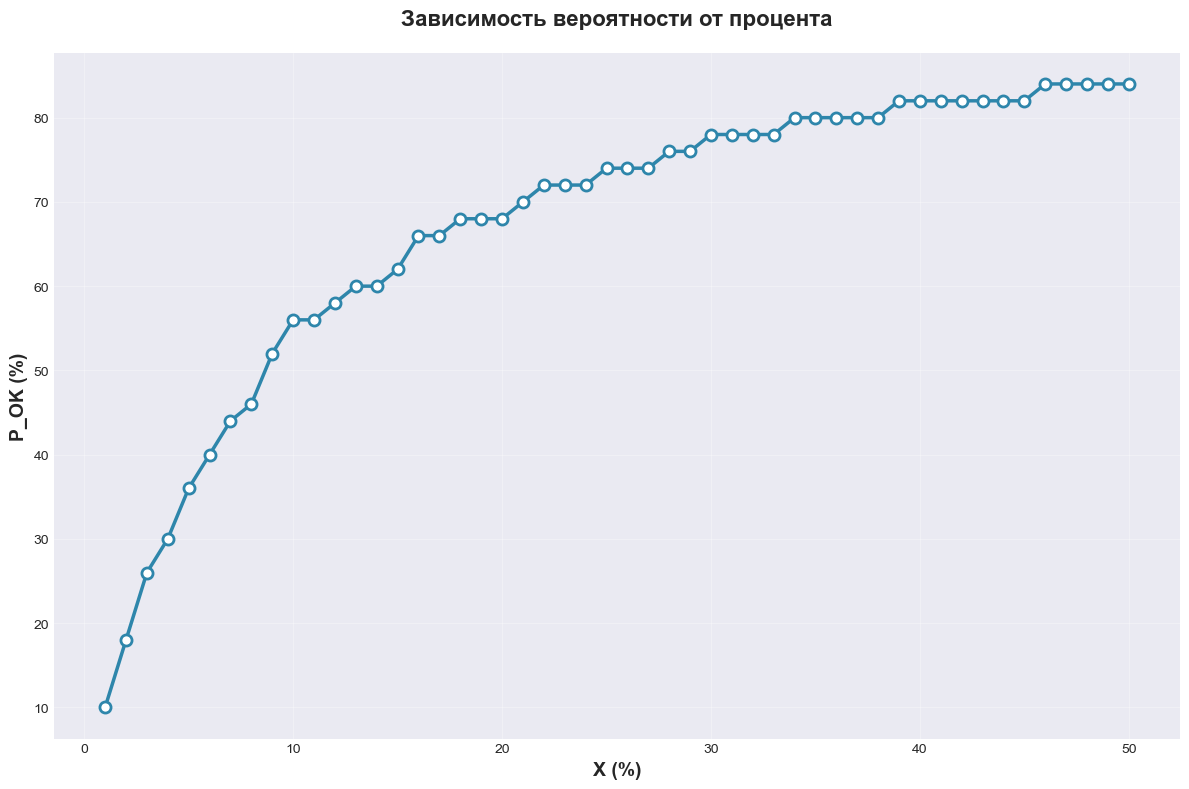

In [135]:
plot_simple_line(ps)

In [121]:
preds

,Unnamed: 0,yearOfBirth,isMale,shippingCountry,premier,customerReturnRate,productType,brandDesc,avgGbpPrice,avgDiscountValue,productReturnRate,pred_proba,pred,true,logistic_price,base_profit
0,0,1998,0,Country_G,0,0.291667,Jeans,Brand_K,29.44,18.05,0.400000,0.369065,0,0,4.416,25.024
1,1,1986,1,Country_G,0,1.000000,Jeans,Brand_K,29.44,18.05,0.388889,0.996373,1,1,8.832,-8.832
2,2,1989,1,Country_I,0,0.083333,Jeans,Brand_K,29.44,18.05,0.388889,0.158980,0,0,4.416,25.024
3,3,1992,0,Country_G,0,0.125000,Jeans,Brand_K,29.44,18.05,0.317460,0.177908,0,0,4.416,25.024
4,4,1973,0,Country_G,0,0.250000,Jeans,Brand_K,29.44,18.05,0.317460,0.275552,0,1,8.832,-8.832
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
960764,960764,2000,1,Country_G,0,0.250000,productType_J,Brand_B,9.48,18.82,0.018868,0.113879,0,0,1.422,8.058
960765,960765,1979,1,Country_G,0,0.500000,productType_J,Brand_B,9.48,18.82,0.018868,0.379006,0,0,1.422,8.058
960766,960766,1998,1,Country_G,0,0.250000,productType_J,Brand_B,9.48,18.82,0.018868,0.111319,0,0,1.422,8.058
960767,960767,1994,1,Country_H,0,0.105263,productType_J,Brand_B,9.48,18.82,0.018868,0.027693,0,0,1.422,8.058


In [129]:
preds_90 = preds.copy()

preds_90['new_profit'] = np.where(preds_90['pred_proba'] >= 0.90, 0, np.where(preds_90['true'] == 1, -preds_90['logistic_price'], preds_90['avgGbpPrice'] - preds_90['logistic_price']))

Новая прибыль если мы с помощью рекомендаций уберём из поля видимости очень высокорисковые продукты (скор больше 0.9)

In [130]:
preds_90.new_profit.sum()

5421067.188500001

Прибыль если мы ничего не сделаем

In [131]:
preds_90.base_profit.sum()

4315451.351999998

In [133]:
(preds_90['new_profit'].sum() - int(preds.base_profit.sum())) / 4315451.351999998

0.25619943276329665

In [65]:
int(preds_increase_5.new_profit.sum())

4503005

In [146]:
5421067.188500001 - 4315451.351999998

1105615.836500003

In [ ]:
preds_increase_5['pred'] == 1

In [46]:
random.random()

0.6634706445300605

In [53]:
preds_increase_5['pred'].sum()

639920

In [136]:
preds

,Unnamed: 0,yearOfBirth,isMale,shippingCountry,premier,customerReturnRate,productType,brandDesc,avgGbpPrice,avgDiscountValue,productReturnRate,pred_proba,pred,true,logistic_price,base_profit
0,0,1998,0,Country_G,0,0.291667,Jeans,Brand_K,29.44,18.05,0.400000,0.369065,0,0,4.416,25.024
1,1,1986,1,Country_G,0,1.000000,Jeans,Brand_K,29.44,18.05,0.388889,0.996373,1,1,8.832,-8.832
2,2,1989,1,Country_I,0,0.083333,Jeans,Brand_K,29.44,18.05,0.388889,0.158980,0,0,4.416,25.024
3,3,1992,0,Country_G,0,0.125000,Jeans,Brand_K,29.44,18.05,0.317460,0.177908,0,0,4.416,25.024
4,4,1973,0,Country_G,0,0.250000,Jeans,Brand_K,29.44,18.05,0.317460,0.275552,0,1,8.832,-8.832
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
960764,960764,2000,1,Country_G,0,0.250000,productType_J,Brand_B,9.48,18.82,0.018868,0.113879,0,0,1.422,8.058
960765,960765,1979,1,Country_G,0,0.500000,productType_J,Brand_B,9.48,18.82,0.018868,0.379006,0,0,1.422,8.058
960766,960766,1998,1,Country_G,0,0.250000,productType_J,Brand_B,9.48,18.82,0.018868,0.111319,0,0,1.422,8.058
960767,960767,1994,1,Country_H,0,0.105263,productType_J,Brand_B,9.48,18.82,0.018868,0.027693,0,0,1.422,8.058


In [138]:
losses = preds[preds['true'] == 1]

KeyboardInterrupt: 

In [141]:
preds[preds['true'] > 0]['base_profit'].sum()

-4343482.362000001

In [143]:
preds['true'].sum()

513673

In [144]:
preds

,Unnamed: 0,yearOfBirth,isMale,shippingCountry,premier,customerReturnRate,productType,brandDesc,avgGbpPrice,avgDiscountValue,productReturnRate,pred_proba,pred,true,logistic_price,base_profit
0,0,1998,0,Country_G,0,0.291667,Jeans,Brand_K,29.44,18.05,0.400000,0.369065,0,0,4.416,25.024
1,1,1986,1,Country_G,0,1.000000,Jeans,Brand_K,29.44,18.05,0.388889,0.996373,1,1,8.832,-8.832
2,2,1989,1,Country_I,0,0.083333,Jeans,Brand_K,29.44,18.05,0.388889,0.158980,0,0,4.416,25.024
3,3,1992,0,Country_G,0,0.125000,Jeans,Brand_K,29.44,18.05,0.317460,0.177908,0,0,4.416,25.024
4,4,1973,0,Country_G,0,0.250000,Jeans,Brand_K,29.44,18.05,0.317460,0.275552,0,1,8.832,-8.832
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
960764,960764,2000,1,Country_G,0,0.250000,productType_J,Brand_B,9.48,18.82,0.018868,0.113879,0,0,1.422,8.058
960765,960765,1979,1,Country_G,0,0.500000,productType_J,Brand_B,9.48,18.82,0.018868,0.379006,0,0,1.422,8.058
960766,960766,1998,1,Country_G,0,0.250000,productType_J,Brand_B,9.48,18.82,0.018868,0.111319,0,0,1.422,8.058
960767,960767,1994,1,Country_H,0,0.105263,productType_J,Brand_B,9.48,18.82,0.018868,0.027693,0,0,1.422,8.058


In [145]:
513673 / 960769

0.534647766528687